In [1]:
from typing import TypedDict
from langchain_core.messages import SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode

import os 
import sys
sys.path.append(os.path.abspath(".."))
from dotenv import load_dotenv
load_dotenv()

c:\Users\davis\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


True

In [2]:
class AgentState(MessagesState):
    next_agent: str  # supervisor decides this

In [3]:
@tool
def search_web(query: str) -> str:
    """Search the web for information"""
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

In [4]:
llm = ChatOpenAI(model="gpt-3.5-turbo")

In [5]:
def supervisor_agent(state: AgentState):
    """Supervisor decides which agent should run next."""

    messages = state["messages"]

    system_msg = SystemMessage(
        content=(
            "You are a supervisor AI. Decide which agent should act next.\n"
            "Options:\n"
            "- researcher → if more information is needed\n"
            "- writer → if a summary or refinement is needed\n"
            "- end → if the task is complete\n"
            "Respond ONLY with one word: researcher, writer, or end."
        )
    )

    response = llm.invoke([system_msg] + messages)
    decision = response.content.strip().lower()

    if decision not in ["researcher", "writer", "end"]:
        decision = "writer"

    return {
        "messages": [response],
        "next_agent": decision
    }

In [6]:
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""

    messages = state["messages"]

    system_msg = SystemMessage(
        content="You are a research assistant. Use the search_web tool to find relevant information."
    )

    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)

    # If tool call exists → route to tools
    if hasattr(response, "tool_calls") and response.tool_calls:
        return {
            "messages": [response],
            "next_agent": "tools"
        }

    # Otherwise → return to supervisor
    return {
        "messages": [response],
        "next_agent": "supervisor"
    }

In [7]:
def writer_agent(state: AgentState):
    """Writer agent that creates summary and may use tools."""

    messages = state["messages"]

    system_message = SystemMessage(
        content="You are a technical writer. You may use tools if needed to improve the summary."
    )

    writer_llm = llm.bind_tools([search_web])
    response = writer_llm.invoke([system_message] + messages)

    # If writer triggers a tool call → go to tools
    if hasattr(response, "tool_calls") and response.tool_calls:
        return {
            "messages": [response],
            "next_agent": "tools"
        }

    # Otherwise → return to supervisor
    return {
        "messages": [response],
        "next_agent": "supervisor"
    }

In [8]:
workflow = StateGraph(AgentState)

workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)
workflow.add_node("tools", ToolNode([search_web]))

In [9]:
workflow.add_edge(START, "supervisor")

workflow.add_conditional_edges(
    "supervisor",
    lambda state: state["next_agent"],
    {
        "researcher": "researcher",
        "writer": "writer",
        "end": END
    }
)

workflow.add_conditional_edges(
    "researcher",
    lambda state: state["next_agent"],
    {
        "tools": "tools",
        "supervisor": "supervisor"
    }
)

workflow.add_conditional_edges(
    "writer",
    lambda state: state["next_agent"],
    {
        "tools": "tools",
        "supervisor": "supervisor"
    }
)

workflow.add_edge("tools", "supervisor")

In [10]:
final_workflow = workflow.compile()

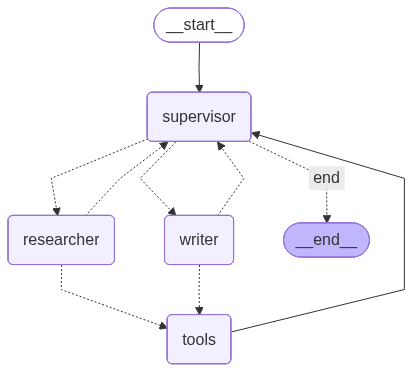

In [11]:
from IPython.display import Image, display

display(Image(final_workflow.get_graph().draw_mermaid_png())) 

In [12]:
response = final_workflow.invoke({
    "messages": "Research about the usecases of agentic AI in the IT industry"
})

for msg in response["messages"]:
    msg.pretty_print()

C:\Users\davis\AppData\Local\Temp\ipykernel_14468\3821390953.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results=3)


================================ Human Message =================================

Research about the usecases of agentic AI in the IT industry
================================== Ai Message ==================================

researcher
================================== Ai Message ==================================
Tool Calls:
  search_web (call_Bt2M8X6EE2FPUEKYgTTD6poi)
 Call ID: call_Bt2M8X6EE2FPUEKYgTTD6poi
  Args:
    query: use cases of agentic AI in the IT industry
================================= Tool Message =================================
Name: search_web

[{'title': 'Agentic AI Use Cases That Prove the Power of Intelligent Automation', 'url': 'https://www.moveworks.com/us/en/resources/blog/agentic-ai-examples-use-cases', 'content': "Table of contents\n\n## Highlights\n\n Agentic AI has rapidly evolved beyond traditional chatbots, enabling autonomous, multi-step workflow execution across enterprise systems.\n The highest-impact use cases share common traits: repetitive proc